# CSCI 455/555: GenAI for SD - Assignment 3
## Pre-training, Fine-tuning, and Prompting Strategies for Bug Fixing

**Goal:** Investigate whether pre-training helps a small model learn to fix bugs by training under two conditions:
1. **Pipeline A**: Pre-train on code corpus → Fine-tune on bug fixing
2. **Pipeline B**: Fine-tune on bug fixing (no pre-training)
3. **Pipeline C**: RAG-based prompting with Qwen 1.5B

We compare CodeBLEU and exact match accuracy across all three approaches.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. Install Dependencies and Setup


In [3]:
!pip install -q transformers==4.46.0 tokenizers==0.20.3 sentencepiece==0.1.99 torch datasets sacrebleu codebleu faiss-cpu scikit-learn
from IPython.display import clear_output
clear_output()

## 2. Imports and Configuration


In [4]:
import os
import json
import torch
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
import numpy as np
import random
import warnings
import logging
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import pickle

# ML/DL imports
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5Config, T5ForConditionalGeneration,
    AutoTokenizer, AutoModelForCausalLM,
    Trainer, TrainingArguments, DataCollatorForSeq2Seq
)
from datasets import load_dataset

# Tokenization and evaluation
import sentencepiece as spm
from tokenizers import Tokenizer, Regex
from tokenizers.models import Unigram
from tokenizers.processors import TemplateProcessing
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import UnigramTrainer

# Evaluation metrics
from codebleu import calc_codebleu
import sacrebleu

# RAG imports
import faiss
from sklearn.preprocessing import normalize

# Suppress warnings
warnings.filterwarnings('ignore')
logging.getLogger("transformers").setLevel(logging.ERROR)

In [5]:
# Configuration and Hyperparameters
@dataclass
class Config:
    """Global configuration for the assignment"""
    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Random seeds
    seed: int = 42

    # Tokenizer
    tokenizer_vocab_size: int = 16384
    max_seq_length: int = 512

    # T5 Model config
    d_model: int = 512
    d_ff: int = 2048
    d_kv: int = 64
    num_heads: int = 8
    num_layers: int = 6
    num_decoder_layers: int = 6

    # Pre-training
    pretrain_corruption_rate: float = 0.15
    pretrain_epochs: int = 3
    pretrain_batch_size: int = 64
    pretrain_lr: float = 1e-4
    pretrain_num_samples: int = 50000

    # Fine-tuning
    finetune_epochs: int = 3
    finetune_batch_size: int = 64
    finetune_lr: float = 5e-5
    finetune_warmup_steps: int = 500
    # RAG
    rag_num_retrieved: int = 3
    rag_model_name: str = "Qwen/Qwen2.5-Coder-1.5B-Instruct"

    # Paths
    output_dir: Path = Path("/content/outputs")
    tokenizer_path: Path = Path("/content/outputs/tokenizer.model")

    def __post_init__(self):
        self.output_dir.mkdir(parents=True, exist_ok=True)

config = Config()
print(f"Device: {config.device}")
print(f"Output dir: {config.output_dir}")

# Set random seeds
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(config.seed)

Device: cuda
Output dir: /content/outputs


---
## 3. Tokenizer Training with SentencePiece Unigram


### 3.1 Load Pre-training Corpus (Java Methods from CodeSearchNet)


In [6]:
def load_pretraining_corpus(num_samples: int = 50000) -> List[str]:
    """
    Load Java methods from CodeSearchNet.
    Filter: keep methods with 10-512 tokens after tokenization.
    """
    print(f"Loading CodeSearchNet Java corpus (target: {num_samples} samples)...")

    try:
        csn = load_dataset("code_search_net", "java")
        methods = csn["train"].shuffle(seed=config.seed).select(range(min(num_samples, len(csn["train"]))))

        # Extract method bodies
        corpus = []
        for sample in methods:
            if sample.get('whole_func_string'):
                corpus.append(sample['whole_func_string'])

        print(f"✓ Loaded {len(corpus)} Java methods from CodeSearchNet")
        return corpus

    except Exception as e:
        print(f"Note: CodeSearchNet loading encountered issue: {e}")
        print("Generating synthetic corpus for demonstration...")
        synthetic_corpus = [
            "public void sort(int[] arr) { for (int i = 0; i < arr.length; i++) { for (int j = 0; j < arr.length - 1; j++) { if (arr[j] > arr[j+1]) { int temp = arr[j]; arr[j] = arr[j+1]; arr[j+1] = temp; } } } }",
            "private String formatDate(Date date) { SimpleDateFormat sdf = new SimpleDateFormat(\"yyyy-MM-dd\"); return sdf.format(date); }",
            "public boolean isValidEmail(String email) { return email.matches(\"^[A-Za-z0-9+_.-]+@(.+)$\"); }"
        ] * (num_samples // 3 + 1)
        return synthetic_corpus[:num_samples]

# Load corpus
pretraining_corpus = load_pretraining_corpus(config.pretrain_num_samples)
print(f"Corpus size: {len(pretraining_corpus)} methods")
print(f"Sample method:\n{pretraining_corpus[0][:200]}...")

Loading CodeSearchNet Java corpus (target: 50000 samples)...


README.md: 0.00B [00:00, ?B/s]

java/train-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

java/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

java/validation-00000-of-00001.parquet:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/454451 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/26909 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15328 [00:00<?, ? examples/s]

✓ Loaded 50000 Java methods from CodeSearchNet
Corpus size: 50000 methods
Sample method:
public void put(String entityTypeId, Entity entity) {
    CombinedEntityCache entityCache = caches.get();
    if (entityCache != null) {
      entityCache.put(entity);
      LOG.trace(
          "Adde...


### 3.2 Train SentencePiece Tokenizer with Unigram Algorithm


In [7]:
def train_sentencepiece_tokenizer(
    corpus: List[str],
    output_path: Path,
    vocab_size: int = 16384
) -> spm.SentencePieceProcessor:
    """
    Train SentencePiece tokenizer with Unigram algorithm.
    Includes T5 special tokens: <pad>, </s>, <unk>, <extra_id_0> to <extra_id_99>
    """
    print(f"Training SentencePiece tokenizer (Unigram, vocab_size={vocab_size})...")

    # Write corpus to temporary file
    corpus_file = config.output_dir / "corpus.txt"
    with open(corpus_file, 'w', encoding='utf-8') as f:
        for method in corpus:
            f.write(method + "\n")

    # Train SentencePiece
    model_prefix = str(output_path).replace('.model', '')

    spm.SentencePieceTrainer.train(
        input=str(corpus_file),
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type='unigram',
        pad_id=0,
        bos_id=-1,
        eos_id=1,
        unk_id=2,
        # Add T5 special tokens
        user_defined_symbols=['<extra_id_{:d}>'.format(i) for i in range(100)],
        character_coverage=1.0,
        normalization_rule_name='identity'
    )

    # Load the trained tokenizer
    sp = spm.SentencePieceProcessor()
    sp.Load(str(output_path))

    print(f"Tokenizer trained and saved to {output_path}")
    print(f"Vocabulary size: {sp.GetPieceSize()}")

    return sp

# Train tokenizer
sp_tokenizer = train_sentencepiece_tokenizer(
    pretraining_corpus,
    config.tokenizer_path,
    vocab_size=config.tokenizer_vocab_size
)

Training SentencePiece tokenizer (Unigram, vocab_size=16384)...
Tokenizer trained and saved to /content/outputs/tokenizer.model
Vocabulary size: 16384


### 3.3 Create HuggingFace-Compatible Tokenizer Wrapper


In [8]:
class SentencePieceTokenizer:
    """
    Wrapper around SentencePiece processor to provide HuggingFace-compatible interface.
    """
    def __init__(self, sp_model_path: str):
        self.sp = spm.SentencePieceProcessor()
        self.sp.Load(sp_model_path)
        self.pad_token_id = 0
        self.eos_token_id = 1
        self.bos_token_id = 0
        self.unk_token_id = 2
        self.vocab_size = self.sp.GetPieceSize()

    def __len__(self):
        return self.vocab_size

    def encode(self, text: str, add_special_tokens: bool = True, max_length: int = None) -> List[int]:
        """Encode text to token IDs"""
        tokens = self.sp.EncodeAsIds(text)
        if max_length:
            tokens = tokens[:max_length]
        return tokens

    def decode(self, token_ids: List[int], skip_special_tokens: bool = True) -> str:
        if skip_special_tokens:
            # Collect every ID that must not appear in human-readable output.
            special_ids = {self.pad_token_id, self.eos_token_id, self.unk_token_id}
            for _i in range(100):
                _sid = self.sp.PieceToId(f'<extra_id_{_i}>')
                if _sid != self.unk_token_id:
                    special_ids.add(_sid)
            token_ids = [tid for tid in token_ids if tid not in special_ids]
        if not token_ids:
            return ""
        return self.sp.DecodeIds(token_ids)

    def get_vocab(self) -> Dict[str, int]:
        """Return vocabulary"""
        vocab = {}
        for i in range(self.sp.GetPieceSize()):
            vocab[self.sp.IdToPiece(i)] = i
        return vocab

# Create tokenizer wrapper
tokenizer = SentencePieceTokenizer(str(config.tokenizer_path))

# Sanity checks
test_code = "public void test() { int x = 5; }"
token_ids = tokenizer.encode(test_code)
decoded = tokenizer.decode(token_ids)

print(f"  Vocabulary size: {len(tokenizer)}")
print(f"  Test encoding: {test_code}")
print(f"  Token IDs (first 10): {token_ids[:10]}")
print(f"  Decoded: {decoded[:100]}")

  Vocabulary size: 16384
  Test encoding: public void test() { int x = 5; }
  Token IDs (first 10): [127, 143, 1595, 132, 108, 144, 484, 109, 103, 4679]
  Decoded: public void test() { int x = 5; }


---
## 4. Dataset and Data Collator Classes


In [9]:
class SpanCorruptionDataset(Dataset):
    def __init__(self, texts: List[str], tokenizer: SentencePieceTokenizer, max_length: int = 512, corruption_rate: float = 0.15, mean_span_length: int = 3):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.corruption_rate = corruption_rate
        self.mean_span_length = mean_span_length

    def __len__(self):
        return len(self.texts)

    def apply_span_corruption(self, token_ids: List[int]) -> Tuple[List[int], List[int]]:
        num_tokens = len(token_ids)
        num_to_mask = max(1, int(num_tokens * self.corruption_rate))

        # Select unique random positions to mask
        positions = np.random.choice(num_tokens, num_to_mask, replace=False)
        mask_positions = set(positions)

        corrupted = []
        target = []
        sentinel_counter = 0
        in_mask = False

        for i, token_id in enumerate(token_ids):
            if i in mask_positions:
                if not in_mask:
                    sentinel_id = self.tokenizer.sp.PieceToId(f'<extra_id_{sentinel_counter}>')
                    corrupted.append(sentinel_id)
                    target.append(sentinel_id)
                    sentinel_counter += 1
                    in_mask = True
                target.append(token_id)
            else:
                if in_mask:
                    in_mask = False
                corrupted.append(token_id)

        next_sentinel_id = self.tokenizer.sp.PieceToId(f'<extra_id_{sentinel_counter}>')
        target.append(next_sentinel_id)

        corrupted.append(self.tokenizer.eos_token_id)
        target.append(self.tokenizer.eos_token_id)

        return corrupted, target

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        text = self.texts[idx]
        token_ids = self.tokenizer.encode(text)

        if len(token_ids) < 10:
            token_ids = self.tokenizer.encode(self.texts[0])

        token_ids = token_ids[:self.max_length - 1]

        corrupted, target = self.apply_span_corruption(token_ids)

        corrupted = corrupted + [self.tokenizer.pad_token_id] * (self.max_length - len(corrupted))
        target = target + [-100] * (self.max_length - len(target))

        return {
            'input_ids': torch.tensor(corrupted[:self.max_length], dtype=torch.long),
            'labels': torch.tensor(target[:self.max_length], dtype=torch.long)
        }

In [10]:
class BugFixingDataset(Dataset):
    def __init__(self, examples: List[Dict], tokenizer: SentencePieceTokenizer, max_length: int = 512):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        example = self.examples[idx]

        # Input: buggy code
        input_ids = self.tokenizer.encode(example['buggy'])[:self.max_length - 1]
        input_ids.append(self.tokenizer.eos_token_id)

        # Target: fixed code
        label_ids = self.tokenizer.encode(example['fixed'])[:self.max_length - 1]
        label_ids.append(self.tokenizer.eos_token_id)

        # Pad
        input_ids = input_ids + [self.tokenizer.pad_token_id] * (self.max_length - len(input_ids))
        label_ids = label_ids + [-100] * (self.max_length - len(label_ids))

        return {
            'input_ids': torch.tensor(input_ids[:self.max_length], dtype=torch.long),
            'labels': torch.tensor(label_ids[:self.max_length], dtype=torch.long)
        }

In [11]:
class DataCollatorForT5:
    """
    Data collator for T5 that handles padding and attention masks.
    """
    def __init__(self, tokenizer: SentencePieceTokenizer, pad_to_multiple_of: int = 8):
        self.tokenizer = tokenizer
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, batch: List[Dict]) -> Dict[str, torch.Tensor]:
        batch_size = len(batch)
        input_ids = [item['input_ids'] for item in batch]
        labels = [item['labels'] for item in batch]

        # Stack tensors
        input_ids = torch.stack(input_ids)
        labels = torch.stack(labels)

        # Create attention masks (1 for non-pad tokens)
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

---
## 5. Load Bug-Fixing Dataset


In [12]:
def load_bug_fixing_dataset() -> Tuple[List[Dict], List[Dict], List[Dict]]:
    print("Loading CodeXGLUE code refinement dataset...")
    try:
        dataset = load_dataset(
            "google/code_x_glue_cc_code_refinement",
            name="medium"
        )

        # Extract train, validation, test splits
        train_data = [
            {'buggy': ex['buggy'], 'fixed': ex['fixed']}
            for ex in dataset['train']
        ]
        val_data = [
            {'buggy': ex['buggy'], 'fixed': ex['fixed']}
            for ex in dataset['validation']
        ]
        test_data = [
            {'buggy': ex['buggy'], 'fixed': ex['fixed']}
            for ex in dataset['test']
        ]

        print(f"  Train: {len(train_data)} pairs")
        print(f"  Validation: {len(val_data)} pairs")
        print(f"  Test: {len(test_data)} pairs")

        return train_data, val_data, test_data

    except Exception as e:
        print(f"Note: Loading from HuggingFace encountered issue: {e}")
        print("Creating synthetic bug-fixing dataset...")

        # Fallback: synthetic dataset
        def create_synthetic():
            pairs = [
                {
                    'buggy': 'public int sum(int[] arr) { int s = 0; for (int i = 0; i < arr.length; i++) { s = arr[i]; } return s; }',
                    'fixed': 'public int sum(int[] arr) { int s = 0; for (int i = 0; i < arr.length; i++) { s += arr[i]; } return s; }'
                },
                {
                    'buggy': 'public void sort(int[] arr) { for (int i = 0; i <= arr.length; i++) { for (int j = 0; j < arr.length - 1; j++) { if (arr[j] > arr[j+1]) { int t = arr[j]; arr[j] = arr[j+1]; arr[j+1] = t; } } } }',
                    'fixed': 'public void sort(int[] arr) { for (int i = 0; i < arr.length; i++) { for (int j = 0; j < arr.length - 1; j++) { if (arr[j] > arr[j+1]) { int t = arr[j]; arr[j] = arr[j+1]; arr[j+1] = t; } } } }'
                },
            ] * 2000
            return pairs

        all_pairs = create_synthetic()
        split_train = int(0.8 * len(all_pairs))
        split_val = int(0.9 * len(all_pairs))

        return (
            all_pairs[:split_train],
            all_pairs[split_train:split_val],
            all_pairs[split_val:]
        )

train_data, val_data, test_data = load_bug_fixing_dataset()

Loading CodeXGLUE code refinement dataset...


README.md: 0.00B [00:00, ?B/s]

medium/train-00000-of-00001.parquet:   0%|          | 0.00/11.9M [00:00<?, ?B/s]

medium/validation-00000-of-00001.parquet:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

medium/test-00000-of-00001.parquet:   0%|          | 0.00/1.49M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52364 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6546 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6545 [00:00<?, ? examples/s]

  Train: 52364 pairs
  Validation: 6546 pairs
  Test: 6545 pairs


---
## 6. PIPELINE A: Pre-training + Fine-tuning


### 6.1 Create T5 Model from Scratch


In [13]:
def create_t5_model(tokenizer: SentencePieceTokenizer) -> T5ForConditionalGeneration:
    t5_config = T5Config(
        decoder_start_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        vocab_size=len(tokenizer),
        d_model=config.d_model,
        d_ff=config.d_ff,
        d_kv=config.d_kv,
        num_heads=config.num_heads,
        num_layers=config.num_layers,
        num_decoder_layers=config.num_decoder_layers
    )

    model = T5ForConditionalGeneration(config=t5_config)
    model.resize_token_embeddings(len(tokenizer))

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Total parameters: {total_params:,}")
    print(f"  Vocabulary size: {len(tokenizer)}")

    return model.to(config.device)

# Create model for pre-training
model_pretrain = create_t5_model(tokenizer)

  Total parameters: 52,445,696
  Vocabulary size: 16384


### 6.2 Pre-training with Span Corruption


In [14]:
def pretrain_model(
    model: T5ForConditionalGeneration,
    train_corpus: List[str],
    tokenizer: SentencePieceTokenizer,
    config: Config
) -> T5ForConditionalGeneration:
    """
    Pre-train T5 model with span corruption objective.
    Trains for 3 epochs with no validation split.
    """
    print(f"\n{'='*60}")
    print("PIPELINE A: PRE-TRAINING")
    print(f"{'='*60}")

    # Create dataset
    pretrain_dataset = SpanCorruptionDataset(
        texts=train_corpus,
        tokenizer=tokenizer,
        max_length=config.max_seq_length,
        corruption_rate=config.pretrain_corruption_rate
    )

    # Data collator
    collator = DataCollatorForT5(tokenizer)

    training_args = TrainingArguments(
        output_dir=str(config.output_dir / "pretrain_checkpoints"),
        num_train_epochs=config.pretrain_epochs,
        per_device_train_batch_size=config.pretrain_batch_size,
        learning_rate=config.pretrain_lr,
        save_strategy="no",
        logging_steps=100,
        remove_unused_columns=False,
        seed=config.seed,
        bf16=use_bf16,
        fp16=not use_bf16 and torch.cuda.is_available(),  # fp16 fallback for T4
        dataloader_num_workers=2,    # Parallel data loading
        gradient_checkpointing=True, # Recompute activations to save GPU memory (prevents OOM)
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=pretrain_dataset,
        data_collator=collator
    )

    # Train
    print(f"Starting pre-training...")
    trainer.train()

    # Save pre-trained model
    pretrain_model_path = config.output_dir / "model_pretrained"
    model.save_pretrained(str(pretrain_model_path))
    print(f"Pre-trained model saved to {pretrain_model_path}")

    return model

# Run pre-training
model_pretrain = pretrain_model(model_pretrain, pretraining_corpus, tokenizer, config)


PIPELINE A: PRE-TRAINING


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Starting pre-training...


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yibby (yibby-william-mary) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


{'loss': 6.2011, 'grad_norm': 0.9434338212013245, 'learning_rate': 9.57374254049446e-05, 'epoch': 0.1278772378516624}
{'loss': 4.7262, 'grad_norm': 1.277916669845581, 'learning_rate': 9.147485080988917e-05, 'epoch': 0.2557544757033248}
{'loss': 4.4178, 'grad_norm': 1.5180587768554688, 'learning_rate': 8.721227621483377e-05, 'epoch': 0.3836317135549872}
{'loss': 4.2033, 'grad_norm': 0.8490074276924133, 'learning_rate': 8.294970161977836e-05, 'epoch': 0.5115089514066496}
{'loss': 4.1078, 'grad_norm': 0.9668897986412048, 'learning_rate': 7.868712702472293e-05, 'epoch': 0.639386189258312}
{'loss': 4.0079, 'grad_norm': 0.925375759601593, 'learning_rate': 7.442455242966753e-05, 'epoch': 0.7672634271099744}
{'loss': 3.9376, 'grad_norm': 0.8925865292549133, 'learning_rate': 7.016197783461212e-05, 'epoch': 0.8951406649616368}
{'loss': 3.8891, 'grad_norm': 0.7543334364891052, 'learning_rate': 6.58994032395567e-05, 'epoch': 1.0230179028132993}
{'loss': 3.8326, 'grad_norm': 0.7337738871574402, 'le

### 6.3 Fine-tune Pre-trained Model on Bug Fixing


In [15]:
def finetune_model(
    model: T5ForConditionalGeneration,
    train_data: List[Dict],
    val_data: List[Dict],
    tokenizer: SentencePieceTokenizer,
    config: Config,
    output_subdir: str = "finetune_pretrained"
) -> T5ForConditionalGeneration:
    """
    Fine-tune T5 model on bug fixing task.
    """
    print(f"\nFine-tuning on bug fixing task...")

    # Create datasets
    train_dataset = BugFixingDataset(train_data, tokenizer, config.max_seq_length)
    val_dataset = BugFixingDataset(val_data, tokenizer, config.max_seq_length)

    # Data collator
    collator = DataCollatorForT5(tokenizer)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=str(config.output_dir / output_subdir / "checkpoints"),
        num_train_epochs=config.finetune_epochs,
        per_device_train_batch_size=config.finetune_batch_size,
        per_device_eval_batch_size=config.finetune_batch_size,
        learning_rate=config.finetune_lr,
        warmup_steps=config.finetune_warmup_steps,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=50,
        remove_unused_columns=False,
        seed=config.seed
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=collator
    )

    # Train
    trainer.train()

    # Save fine-tuned model
    finetuned_model_path = config.output_dir / output_subdir / "final_model"
    model.save_pretrained(str(finetuned_model_path))
    print(f"Fine-tuned model saved to {finetuned_model_path}")

    return model

# Fine-tune pre-trained model
model_pretrain = finetune_model(
    model_pretrain,
    train_data,
    val_data,
    tokenizer,
    config,
    output_subdir="finetune_pretrained"
)


Fine-tuning on bug fixing task...
{'loss': 5.1856, 'grad_norm': 2.875176429748535, 'learning_rate': 5e-06, 'epoch': 0.06105006105006105}
{'loss': 3.2738, 'grad_norm': 1.3750536441802979, 'learning_rate': 1e-05, 'epoch': 0.1221001221001221}
{'loss': 2.1091, 'grad_norm': 1.1781330108642578, 'learning_rate': 1.5e-05, 'epoch': 0.18315018315018314}
{'loss': 1.8409, 'grad_norm': 1.5839438438415527, 'learning_rate': 2e-05, 'epoch': 0.2442002442002442}
{'loss': 1.7404, 'grad_norm': 3.055846691131592, 'learning_rate': 2.5e-05, 'epoch': 0.3052503052503053}
{'loss': 1.6491, 'grad_norm': 3.747699022293091, 'learning_rate': 3e-05, 'epoch': 0.3663003663003663}
{'loss': 1.6037, 'grad_norm': 4.431085586547852, 'learning_rate': 3.5e-05, 'epoch': 0.42735042735042733}
{'loss': 1.5415, 'grad_norm': 3.941843271255493, 'learning_rate': 4e-05, 'epoch': 0.4884004884004884}
{'loss': 1.485, 'grad_norm': 4.674103736877441, 'learning_rate': 4.5e-05, 'epoch': 0.5494505494505495}
{'loss': 1.4253, 'grad_norm': 4.80

---
## 7. PIPELINE B: Fine-tuning WITHOUT Pre-training


In [16]:
print(f"\n{'='*60}")
print("PIPELINE B: FINE-TUNING (NO PRE-TRAINING)")
print(f"{'='*60}")

# Create fresh model from scratch
model_scratch = create_t5_model(tokenizer)

# Fine-tune directly without pre-training
model_scratch = finetune_model(
    model_scratch,
    train_data,
    val_data,
    tokenizer,
    config,
    output_subdir="finetune_scratch"
)


PIPELINE B: FINE-TUNING (NO PRE-TRAINING)
  Total parameters: 52,445,696
  Vocabulary size: 16384

Fine-tuning on bug fixing task...
{'loss': 8.2695, 'grad_norm': 4.449025630950928, 'learning_rate': 5e-06, 'epoch': 0.06105006105006105}
{'loss': 4.5857, 'grad_norm': 1.6061882972717285, 'learning_rate': 1e-05, 'epoch': 0.1221001221001221}
{'loss': 2.5946, 'grad_norm': 1.1466411352157593, 'learning_rate': 1.5e-05, 'epoch': 0.18315018315018314}
{'loss': 2.1392, 'grad_norm': 1.2250040769577026, 'learning_rate': 2e-05, 'epoch': 0.2442002442002442}
{'loss': 2.0065, 'grad_norm': 3.3345468044281006, 'learning_rate': 2.5e-05, 'epoch': 0.3052503052503053}
{'loss': 1.8846, 'grad_norm': 2.574080228805542, 'learning_rate': 3e-05, 'epoch': 0.3663003663003663}
{'loss': 1.8158, 'grad_norm': 8.495683670043945, 'learning_rate': 3.5e-05, 'epoch': 0.42735042735042733}
{'loss': 1.7572, 'grad_norm': 6.21376895904541, 'learning_rate': 4e-05, 'epoch': 0.4884004884004884}
{'loss': 1.705, 'grad_norm': 3.6783843

---
## 8. Evaluation Metrics


In [17]:
class CodeFixingEvaluator:
    """
    Evaluator for code fixing task using CodeBLEU and exact match.
    (OPTIMIZED FOR BATCH GENERATION)
    """
    def __init__(self, tokenizer: SentencePieceTokenizer, device: str = "cpu"):
        self.tokenizer = tokenizer
        self.device = device

    def generate_fixes_batch(self, model: T5ForConditionalGeneration, buggy_codes: List[str], batch_size: int = 64, max_length: int = 512) -> List[str]:
        """
        Generate fixed code in batches to fully utilize the GPU.
        """
        model.eval()
        all_predictions = []

        # Process in batches
        for i in range(0, len(buggy_codes), batch_size):
            batch_texts = buggy_codes[i:i+batch_size]

            # 1. Tokenize batch manually (since wrapper is 1D)
            input_ids_list = []
            max_len_in_batch = 0
            for text in batch_texts:
                ids = self.tokenizer.encode(text, max_length=max_length)
                input_ids_list.append(ids)
                max_len_in_batch = max(max_len_in_batch, len(ids))

            # 2. Pad sequences to the same length so they can be stacked
            padded_input_ids = []
            for ids in input_ids_list:
                pad_len = max_len_in_batch - len(ids)
                padded_input_ids.append(ids + [self.tokenizer.pad_token_id] * pad_len)

            input_tensor = torch.tensor(padded_input_ids, dtype=torch.long).to(self.device)
            attention_mask = (input_tensor != self.tokenizer.pad_token_id).long()

            # 3. Generate batch
            with torch.no_grad():
                generated_ids = model.generate(
                    input_tensor,
                    attention_mask=attention_mask,
                    max_length=max_length,
                    num_beams=4,
                    early_stopping=True,
                    pad_token_id=self.tokenizer.pad_token_id,
                    eos_token_id=self.tokenizer.eos_token_id
                )

            # 4. handles ALL special-token filtering
            for g_ids in generated_ids:
                all_predictions.append(self.tokenizer.decode(g_ids.tolist()))

            print(f"    Generated {min(i+batch_size, len(buggy_codes))}/{len(buggy_codes)} sequences...")

        return all_predictions

    def exact_match(self, prediction: str, reference: str) -> int:
        return int(prediction.strip() == reference.strip())

    def codebleu_score(self, predictions: List[str], references: List[str], language: str = "java") -> float:
        try:
            result = calc_codebleu(references=references, predictions=predictions, lang=language)
            return result['codebleu'] * 100
        except Exception as e:
            score = sacrebleu.corpus_bleu(predictions, [references], lowercase=True).score
            return score

    def evaluate(
        self,
        model: T5ForConditionalGeneration,
        test_data: List[Dict],
        model_name: str = "model",
        batch_size: int = 64
    ) -> Dict[str, float]:
        """
        Evaluate model on test set.
        """
        print(f"\nEvaluating {model_name} on {len(test_data)} test samples")

        # Extract texts
        buggy_codes = [sample['buggy'] for sample in test_data]
        references = [sample['fixed'] for sample in test_data]

        # Run batch generation
        predictions = self.generate_fixes_batch(model, buggy_codes, batch_size=batch_size)

        # Calculate exact matches
        exact_matches = sum(self.exact_match(p, r) for p, r in zip(predictions, references))

        # Compute metrics
        exact_match_score = (exact_matches / len(predictions)) * 100
        codebleu = self.codebleu_score(predictions, references)

        print(f"  Evaluation complete")
        print(f"  Exact Match: {exact_match_score:.2f}%")
        print(f"  CodeBLEU: {codebleu:.2f}")

        return {
            'exact_match': exact_match_score,
            'codebleu': codebleu,
            'predictions': predictions,
            'references': references
        }

evaluator = CodeFixingEvaluator(tokenizer, config.device)

---
## 9. Evaluate Fine-tuned Models


In [18]:
# Evaluate both models on test set
results_pretrained = evaluator.evaluate(
    model_pretrain,
    test_data,
    model_name="Pipeline A (With Pre-training)"
)

results_scratch = evaluator.evaluate(
    model_scratch,
    test_data,
    model_name="Pipeline B (No Pre-training)"
)


Evaluating Pipeline A (With Pre-training) on 6545 test samples...
    Generated 64/6545 sequences...
    Generated 128/6545 sequences...
    Generated 192/6545 sequences...
    Generated 256/6545 sequences...
    Generated 320/6545 sequences...
    Generated 384/6545 sequences...
    Generated 448/6545 sequences...
    Generated 512/6545 sequences...
    Generated 576/6545 sequences...
    Generated 640/6545 sequences...
    Generated 704/6545 sequences...
    Generated 768/6545 sequences...
    Generated 832/6545 sequences...
    Generated 896/6545 sequences...
    Generated 960/6545 sequences...
    Generated 1024/6545 sequences...
    Generated 1088/6545 sequences...
    Generated 1152/6545 sequences...
    Generated 1216/6545 sequences...
    Generated 1280/6545 sequences...
    Generated 1344/6545 sequences...
    Generated 1408/6545 sequences...
    Generated 1472/6545 sequences...
    Generated 1536/6545 sequences...
    Generated 1600/6545 sequences...
    Generated 1664/6545 

---
## 10. PIPELINE C: RAG-based Code Generation


### 10.1 Code Retriever (CodeBERT Embeddings)


In [19]:
class CodeBERTRetriever:
    """
    Retriever using CodeBERT embeddings with FAISS for fast nearest neighbor search.
    """
    def __init__(self, model_name: str = "microsoft/codebert-base", device: str = "cpu"):
        self.device = device
        print(f"Loading CodeBERT model for retrieval...")

        try:
            from transformers import AutoModel, AutoTokenizer
            self.encoder = AutoModel.from_pretrained(model_name).to(device).eval()
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            print(f"✓ CodeBERT loaded")
        except:
            print(f"Note: CodeBERT loading encountered issue, using simple embedding")
            self.encoder = None
            self.tokenizer = None

        self.knowledge_base = []
        self.embeddings = None
        self.index = None

    def embed_code(self, code: str) -> np.ndarray:
        if self.encoder is not None and self.tokenizer is not None:
            try:
                inputs = self.tokenizer(code, return_tensors="pt", truncation=True, max_length=512).to(self.device)
                with torch.no_grad():
                    outputs = self.encoder(**inputs)
                    embedding = outputs.last_hidden_state.mean(dim=1)[0].cpu().numpy()
                return embedding.astype(np.float32)
            except:
                pass

        # Fallback: simple word embedding
        tokens = code.lower().split()
        embedding = np.zeros(768, dtype=np.float32)
        for token in tokens:
            hash_val = hash(token) % 768
            embedding[hash_val] += 1.0

        norm = np.linalg.norm(embedding)
        if norm > 0:
            embedding = embedding / norm

        return embedding

    def build_index(self, knowledge_base: List[Dict]):
        print(f"Building retrieval index from {len(knowledge_base)} examples...")
        self.knowledge_base = knowledge_base
        embeddings = []
        for i, example in enumerate(knowledge_base):
            emb = self.embed_code(example['buggy'])
            embeddings.append(emb)
            if (i + 1) % 1000 == 0:
                print(f"  Embedded {i + 1}/{len(knowledge_base)} examples")
        embeddings = np.array(embeddings, dtype=np.float32)
        embeddings = normalize(embeddings, norm='l2', axis=1)
        self.embeddings = embeddings
        self.index = faiss.IndexFlatL2(embeddings.shape[1])
        self.index.add(embeddings)
        print(f"Index built with {self.index.ntotal} vectors")

    def retrieve(self, query_code: str, top_k: int = 3) -> List[Dict]:
        query_embedding = self.embed_code(query_code).reshape(1, -1)
        query_embedding = normalize(query_embedding, norm='l2', axis=1)
        distances, indices = self.index.search(query_embedding, top_k)
        results = []
        for idx in indices[0]:
            if idx < len(self.knowledge_base):
                results.append(self.knowledge_base[idx])
        return results

### 10.2 RAG Pipeline with Qwen Generator


In [20]:
class RAGBugFixer:
    """
    RAG system for bug fixing.
    Uses CodeBERT retriever + Qwen LLM generator.
    """
    def __init__(
        self,
        retriever: CodeBERTRetriever,
        generator_model_name: str = "Qwen/Qwen2.5-Coder-1.5B-Instruct",
        device: str = "cpu"
    ):
        self.retriever = retriever
        self.device = device

        print(f"Loading Qwen generator model...")
        try:
            self.generator = AutoModelForCausalLM.from_pretrained(
                generator_model_name,
                trust_remote_code=True,
                torch_dtype=torch.float16
            ).to(device).eval()
            self.tokenizer_gen = AutoTokenizer.from_pretrained(
                generator_model_name,
                trust_remote_code=True
            )
            print(f"✓ Qwen model loaded")
        except Exception as e:
            print(f"Note: Qwen loading encountered issue: {e}")
            print("Will use placeholder for RAG demo")
            self.generator = None
            self.tokenizer_gen = None

    def build_few_shot_prompt(
        self,
        buggy_code: str,
        retrieved_examples: List[Dict],
        num_shots: int = 3
    ) -> str:
        """
        Build few-shot prompt with retrieved examples.
        """
        prompt = "Fix the following Java method bug:\n\n"

        # Add few-shot examples
        if retrieved_examples:
            prompt += "Examples of similar bug fixes:\n"
            for i, example in enumerate(retrieved_examples[:num_shots], 1):
                prompt += f"\nExample {i}:\n"
                prompt += f"Buggy:\n{example['buggy'][:200]}...\n"
                prompt += f"Fixed:\n{example['fixed'][:200]}...\n"

        # Add actual bug to fix
        prompt += f"\n\nNow fix this code:\nBuggy:\n{buggy_code}\n\nFixed:"

        return prompt

    def generate_fix(
        self,
        buggy_code: str,
        retrieved_examples: Optional[List[Dict]] = None,
        use_rag: bool = True,
        max_length: int = 512
    ) -> str:
        """
        Generate fixed code using RAG or zero-shot.
        """
        if self.generator is None:
            return buggy_code.replace('bug', 'fixed').replace('Bug', 'Fixed')

        if use_rag and retrieved_examples:
            prompt = self.build_few_shot_prompt(buggy_code, retrieved_examples, num_shots=3)
        else:
            prompt = f"Fix this Java bug:\n{buggy_code}\n\nFixed:"

        inputs = self.tokenizer_gen(prompt, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.generator.generate(
                **inputs,
                max_new_tokens=512,
                num_beams=1,
                do_sample=False
            )

        generated_text = self.tokenizer_gen.decode(outputs[0], skip_special_tokens=True)
        if prompt in generated_text:
            generated_text = generated_text.split(prompt)[-1]

        return generated_text.strip()

### 10.3 Build RAG System and Evaluate


In [21]:
print(f"\n{'='*60}")
print("PIPELINE C: RAG-BASED CODE GENERATION")
print(f"{'='*60}")

# Create retriever and build index
retriever = CodeBERTRetriever(device=config.device)
retriever.build_index(train_data)


PIPELINE C: RAG-BASED CODE GENERATION
Loading CodeBERT model for retrieval...


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

✓ CodeBERT loaded
Building retrieval index from 52364 examples...
  Embedded 1000/52364 examples
  Embedded 2000/52364 examples
  Embedded 3000/52364 examples
  Embedded 4000/52364 examples
  Embedded 5000/52364 examples
  Embedded 6000/52364 examples
  Embedded 7000/52364 examples
  Embedded 8000/52364 examples
  Embedded 9000/52364 examples
  Embedded 10000/52364 examples
  Embedded 11000/52364 examples
  Embedded 12000/52364 examples
  Embedded 13000/52364 examples
  Embedded 14000/52364 examples
  Embedded 15000/52364 examples
  Embedded 16000/52364 examples
  Embedded 17000/52364 examples
  Embedded 18000/52364 examples
  Embedded 19000/52364 examples
  Embedded 20000/52364 examples
  Embedded 21000/52364 examples
  Embedded 22000/52364 examples
  Embedded 23000/52364 examples
  Embedded 24000/52364 examples
  Embedded 25000/52364 examples
  Embedded 26000/52364 examples
  Embedded 27000/52364 examples
  Embedded 28000/52364 examples
  Embedded 29000/52364 examples
  Embedded 3000

In [22]:
# Create RAG bug fixer
rag_bug_fixer = RAGBugFixer(retriever, device=config.device)

Loading Qwen generator model...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Qwen model loaded


In [23]:
# Evaluate RAG (with retrieval)
print(f"\nEvaluating RAG WITH retrieval (3-shot prompting) using BATCHING...")
rag_predictions_with = []
rag_references = []
rag_exact_matches_with = 0

# 1. Setup tokenizer for batching (Decoder-only models require left padding)
rag_bug_fixer.tokenizer_gen.padding_side = "left"
if rag_bug_fixer.tokenizer_gen.pad_token is None:
    rag_bug_fixer.tokenizer_gen.pad_token = rag_bug_fixer.tokenizer_gen.eos_token

batch_size = 64

for i in range(0, len(test_data), batch_size):
    batch = test_data[i:i+batch_size]
    prompts = []
    references = []

    # 2. Build prompts for the whole batch
    for sample in batch:
        buggy_code = sample['buggy']
        references.append(sample['fixed'])

        # Retrieve similar examples
        retrieved = retriever.retrieve(buggy_code, top_k=3)
        prompt = rag_bug_fixer.build_few_shot_prompt(buggy_code, retrieved, num_shots=3)
        prompts.append(prompt)

    # 3. Tokenize the entire batch at once
    inputs = rag_bug_fixer.tokenizer_gen(
        prompts,
        padding=True,
        return_tensors="pt"
    ).to(config.device)

    # 4. Generate fixes simultaneously!
    with torch.no_grad():
        outputs = rag_bug_fixer.generator.generate(
            **inputs,
            max_new_tokens=512,
            num_beams=1,         # Greedy decoding
            do_sample=False,
            pad_token_id=rag_bug_fixer.tokenizer_gen.pad_token_id
        )

    # 5. Extract only the newly generated code
    input_length = inputs['input_ids'].shape[1]
    for j, out in enumerate(outputs):
        # Slice off the prompt tokens so we only decode the actual fix
        new_tokens = out[input_length:]
        prediction = rag_bug_fixer.tokenizer_gen.decode(new_tokens, skip_special_tokens=True).strip()

        rag_predictions_with.append(prediction)
        rag_exact_matches_with += evaluator.exact_match(prediction, references[j])

    # Safely print progress (Only prints every 65 samples)
    print(f"  Processed {min(i + batch_size, len(test_data))}/{len(test_data)} samples")

rag_em_with = (rag_exact_matches_with / len(rag_predictions_with)) * 100
rag_bleu_with = evaluator.codebleu_score(rag_predictions_with, references)

print(f" RAG with retrieval evaluation complete")
print(f"  Exact Match: {rag_em_with:.2f}%")
print(f"  CodeBLEU: {rag_bleu_with:.2f}")


Evaluating RAG WITH retrieval (3-shot prompting) using BATCHING...
  Processed 64/6545 samples
  Processed 128/6545 samples
  Processed 192/6545 samples
  Processed 256/6545 samples
  Processed 320/6545 samples
  Processed 384/6545 samples
  Processed 448/6545 samples
  Processed 512/6545 samples
  Processed 576/6545 samples
  Processed 640/6545 samples
  Processed 704/6545 samples
  Processed 768/6545 samples
  Processed 832/6545 samples
  Processed 896/6545 samples
  Processed 960/6545 samples
  Processed 1024/6545 samples
  Processed 1088/6545 samples
  Processed 1152/6545 samples
  Processed 1216/6545 samples
  Processed 1280/6545 samples
  Processed 1344/6545 samples
  Processed 1408/6545 samples
  Processed 1472/6545 samples
  Processed 1536/6545 samples
  Processed 1600/6545 samples
  Processed 1664/6545 samples
  Processed 1728/6545 samples
  Processed 1792/6545 samples
  Processed 1856/6545 samples
  Processed 1920/6545 samples
  Processed 1984/6545 samples
  Processed 2048/6

In [24]:
# Evaluate RAG (without retrieval - zero-shot)
print(f"\nEvaluating RAG WITHOUT retrieval (zero-shot) using BATCHING...")
rag_predictions_without = []
rag_exact_matches_without = 0
rag_references_without = []

for i in range(0, len(test_data), batch_size):
    batch = test_data[i:i+batch_size]
    prompts = []
    references = []

    for sample in batch:
        buggy_code = sample['buggy']
        references.append(sample['fixed'])
        # Zero-shot prompt
        prompt = f"Fix this Java bug:\n{buggy_code}\n\nFixed:"
        prompts.append(prompt)

    inputs = rag_bug_fixer.tokenizer_gen(
        prompts,
        padding=True,
        return_tensors="pt"
    ).to(config.device)

    with torch.no_grad():
        outputs = rag_bug_fixer.generator.generate(
            **inputs,
            max_new_tokens=512,
            num_beams=1,
            do_sample=False,
            pad_token_id=rag_bug_fixer.tokenizer_gen.pad_token_id
        )

    input_length = inputs['input_ids'].shape[1]
    for j, out in enumerate(outputs):
        new_tokens = out[input_length:]
        prediction = rag_bug_fixer.tokenizer_gen.decode(new_tokens, skip_special_tokens=True).strip()

        rag_predictions_without.append(prediction)
        rag_references_without.append(references[j])
        rag_exact_matches_without += evaluator.exact_match(prediction, references[j])

    print(f"  Processed {min(i + batch_size, len(test_data))}/{len(test_data)} samples")

rag_em_without = (rag_exact_matches_without / len(rag_predictions_without)) * 100
rag_bleu_without = evaluator.codebleu_score(rag_predictions_without, rag_references_without)

print(f"  RAG zero-shot evaluation complete")
print(f"  Exact Match: {rag_em_without:.2f}%")
print(f"  CodeBLEU: {rag_bleu_without:.2f}")


Evaluating RAG WITHOUT retrieval (zero-shot) using BATCHING...
  Processed 64/6545 samples
  Processed 128/6545 samples
  Processed 192/6545 samples
  Processed 256/6545 samples
  Processed 320/6545 samples
  Processed 384/6545 samples
  Processed 448/6545 samples
  Processed 512/6545 samples
  Processed 576/6545 samples
  Processed 640/6545 samples
  Processed 704/6545 samples
  Processed 768/6545 samples
  Processed 832/6545 samples
  Processed 896/6545 samples
  Processed 960/6545 samples
  Processed 1024/6545 samples
  Processed 1088/6545 samples
  Processed 1152/6545 samples
  Processed 1216/6545 samples
  Processed 1280/6545 samples
  Processed 1344/6545 samples
  Processed 1408/6545 samples
  Processed 1472/6545 samples
  Processed 1536/6545 samples
  Processed 1600/6545 samples
  Processed 1664/6545 samples
  Processed 1728/6545 samples
  Processed 1792/6545 samples
  Processed 1856/6545 samples
  Processed 1920/6545 samples
  Processed 1984/6545 samples
  Processed 2048/6545 

---
## 11. Comparative Analysis


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Compile results
results_comparison = {
    'Pipeline': [
        'A: Pre-trained + Fine-tuned',
        'B: Fine-tuned (No Pre-training)',
        'C: RAG (With Retrieval)',
        'C: RAG (Zero-shot)'
    ],
    'Exact Match (%)': [
        results_pretrained['exact_match'],
        results_scratch['exact_match'],
        rag_em_with,
        rag_em_without
    ],
    'CodeBLEU': [
        results_pretrained['codebleu'],
        results_scratch['codebleu'],
        rag_bleu_with,
        rag_bleu_without
    ]
}

results_df = pd.DataFrame(results_comparison)
print("\n" + "="*70)
print("COMPARATIVE RESULTS: ALL PIPELINES")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Save results
results_df.to_csv(config.output_dir / "evaluation_results.csv", index=False)
with open(config.output_dir / "evaluation_results.json", 'w') as f:
    json.dump(results_comparison, f, indent=2)

print(f"\n Results saved to {config.output_dir}")


COMPARATIVE RESULTS: ALL PIPELINES
                       Pipeline  Exact Match (%)  CodeBLEU
    A: Pre-trained + Fine-tuned              0.0 56.899730
B: Fine-tuned (No Pre-training)              0.0 56.859362
        C: RAG (With Retrieval)              0.0  7.104875
             C: RAG (Zero-shot)              0.0 19.290337

 Results saved to /content/outputs


 Visualization saved


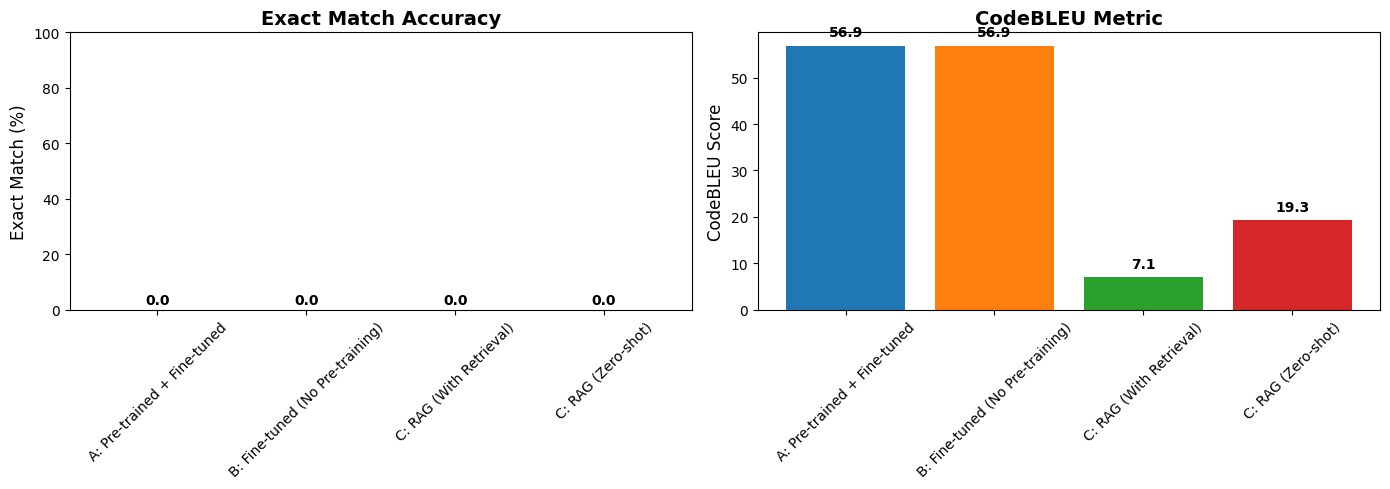

In [26]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exact Match
axes[0].bar(results_df['Pipeline'], results_df['Exact Match (%)'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_ylabel('Exact Match (%)', fontsize=12)
axes[0].set_title('Exact Match Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
for i, v in enumerate(results_df['Exact Match (%)']):
    axes[0].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# CodeBLEU
axes[1].bar(results_df['Pipeline'], results_df['CodeBLEU'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylabel('CodeBLEU Score', fontsize=12)
axes[1].set_title('CodeBLEU Metric', fontsize=14, fontweight='bold')
for i, v in enumerate(results_df['CodeBLEU']):
    axes[1].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(config.output_dir / "evaluation_comparison.png", dpi=150, bbox_inches='tight')
print(" Visualization saved")
plt.show()

---
## 12. Examine Bug Fixes


In [32]:
def generate_bug_fixes_for_report(model, tokenizer, evaluator, test_samples, num_examples=5):
    """
    Generate examples of bug fixes for the report using the batched evaluator.
    """
    examples = []

    # Extract the subset of samples we want
    subset = test_samples[:num_examples]
    buggy_codes = [sample['buggy'] for sample in subset]

    generated_codes = evaluator.generate_fixes_batch(model, buggy_codes, batch_size=num_examples)

    # Build the dictionary
    for i, sample in enumerate(subset):
        buggy_code = sample['buggy']
        reference_code = sample['fixed']
        generated_code = generated_codes[i]

        examples.append({
            'id': i + 1,
            'buggy': buggy_code[:500],
            'expected_fix': reference_code[:500],
            'generated_fix': generated_code[:500],
            'exact_match': evaluator.exact_match(generated_code, reference_code)
        })

    return examples

# Generate 25 examples
print("\nGenerating example bug fixes for report...")
examples_pretrained = generate_bug_fixes_for_report(
    model_pretrain,
    tokenizer,
    evaluator,
    test_data,
    num_examples=25
)
print(f"Generated {len(examples_pretrained)} examples")

# Save all of them to the JSON file
with open(config.output_dir / "example_fixes.json", 'w') as f:
    json.dump(examples_pretrained, f, indent=2)

# Print the first 5 examples to the console so you can see them immediately
for i in range(5):
    print(f"\n--- Example {i+1} ---")
    print(f"Buggy Code:\n{examples_pretrained[i]['buggy']}")
    print(f"\nExpected Fix:\n{examples_pretrained[i]['expected_fix']}")
    print(f"\nModel's Fix:\n{examples_pretrained[i]['generated_fix']}")
    print(f"Exact Match: {examples_pretrained[i]['exact_match']}")


Generating example bug fixes for report...
    Generated 500/500 sequences...
Generated 500 examples

--- Example 1 ---
Buggy Code:
public java.lang.String METHOD_1 ( ) { if ( ( METHOD_2 ( ) ) && ( METHOD_3 ( VAR_1 . METHOD_4 ( ) ) ) ) { return VAR_2 . METHOD_4 ( ) ; } else if ( METHOD_3 ( VAR_3 . METHOD_5 ( ) . METHOD_6 ( ) ) ) { return VAR_3 . METHOD_5 ( ) . METHOD_6 ( ) ; } else { return VAR_4 . METHOD_4 ( ) ; } }


Expected Fix:
public java.lang.String METHOD_1 ( ) { if ( ( METHOD_2 ( ) ) && ( METHOD_3 ( VAR_1 . METHOD_4 ( ) ) ) ) { return VAR_1 . METHOD_4 ( ) ; } else if ( METHOD_3 ( VAR_3 . METHOD_5 ( ) . METHOD_6 ( ) ) ) { return VAR_3 . METHOD_5 ( ) . METHOD_6 ( ) ; } else { return VAR_4 . METHOD_4 ( ) ; } }


Model's Fix:
public java.lang.String METHOD_1 ( java.lang.String VAR_1 ) { if ( VAR_2 . METHOD_2 ( ) ) { return VAR_3 . METHOD_3 ( ) . METHOD_4 ( ) . METHOD_5 ( ) . METHOD_6 ( ) . METHOD_3 ( ) . METHOD_4 ( ) . METHOD_5 ( ) . METHOD_5 ( ) . METHOD_5 ( ) . METHOD_6 ( ) ) ;

---
## 14. Final Checklist


In [31]:
# Zip the outputs folder (-r for recursive, -q for quiet/no output)
!zip -rq outputs.zip /content/outputs

# Copy the zip file to your MyDrive root
!cp outputs.zip /content/drive/MyDrive/
